# Walmart Store Sales Forecasting — LightGBM

**MLflow experiment:** `LightGBM_Training` (runs: EDA, Cleaning,
Feature_Engineering, Baseline, Feature_Selection, HPO_Optuna (+nested trials),
Loss_Target_Experiments, CrossValidation, Final_Pipeline).

## Why LightGBM for this task

LightGBM is a **histogram-based** gradient boosting implementation:
* continuous features are bucketed into bins (default 255) — split search is
  O(#bins) instead of O(#rows);
* trees grow **leaf-wise** (at every step the leaf with the largest loss
  reduction is split) — for the same leaf budget this produces deeper,
  asymmetric, more accurate trees than level-wise XGBoost, at a higher
  overfitting risk (controlled via `num_leaves` / `min_child_samples`);
* GOSS/EFB optimisations make it train in seconds on our 421k-row table.

Tree ensembles remain the strongest class for retail forecasting (the M5
competition — also Walmart data — was won with LightGBM): they digest
categorical IDs (Store/Dept), non-linear interactions (store x season x
holiday) and need no scaling. `objective="l1"` + `sample_weight=5` on holiday
weeks means we **optimise the competition WMAE directly**.


In [1]:
# Colab / Kaggle: run this cell first (most other dependencies are preinstalled).
# NOTE: this notebook imports preprocessing.py and evaluation.py from the repo
# root - on Colab/Kaggle upload those two files next to the notebook first
# (Files pane -> Upload), or clone the repo and copy them here.
%pip install -q seaborn mlflow dagshub optuna lightgbm


Note: you may need to restart the kernel to use updated packages.


In [2]:
import os, gc, json, time, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import mlflow

# shared project modules (same code for both team members - see README)
import preprocessing as prep
import evaluation as ev
from preprocessing import BASE_COLS, MD_COLS, WalmartFeatureBuilder, \
    feature_columns, log1p_clip, expm1_inv, calendar_frame
from evaluation import wmae

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
sns.set_style("whitegrid")
SEED = 42
np.random.seed(SEED)
os.makedirs("pictures", exist_ok=True)   # README figures are saved here

# preprocessing.py / evaluation.py are packaged with every logged model so the
# registered pipeline can be loaded anywhere (see code_paths in log_model calls)
CODE_PATHS = ["preprocessing.py", "evaluation.py"]

ARCH = "LightGBM"


C:\Users\Test\ML\ML FINAL\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# ------------------- MLflow tracking (DagsHub) -------------------
# TODO: create a repo on dagshub.com and fill in your username / repo name
import dagshub

DAGSHUB_USER = "rkvit23"     # <--- fill in your DagsHub username
DAGSHUB_REPO = "ML-FINAL"          # <--- fill in your DagsHub repo name

dagshub.init(repo_owner=DAGSHUB_USER, repo_name=DAGSHUB_REPO, mlflow=True)
mlflow.set_tracking_uri(f"https://dagshub.com/rkvit23/ML-FINAL.mlflow")

EXPERIMENT_NAME = f"{ARCH}_Training"       # one experiment per architecture
mlflow.set_experiment(EXPERIMENT_NAME)
print("MLflow experiment:", EXPERIMENT_NAME)


❗❗❗ AUTHORIZATION REQUIRED ❗❗❗



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=cbc204a3-b70d-45e6-80eb-abcfd47ac172&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=2effa484c8311cf216acbbdbe6487028f4a4d2d01873ac64c4fc80904ca84aed




Accessing as rkvit23

Initialized MLflow to track repo "rkvit23/ML-FINAL"

Repository rkvit23/ML-FINAL initialized!

2026/07/09 14:14:06 INFO mlflow.tracking.fluent: Experiment with name 'LightGBM_Training' does not exist. Creating a new experiment.


MLflow experiment: LightGBM_Training


In [4]:
# ------------------- Load data -------------------
# Data locations are listed in preprocessing.CANDIDATE_DIRS (local folder,
# Kaggle competition mount, /content/data on Colab). pandas reads .csv.zip
# directly, no unzipping needed.
train_raw, test_raw, features_raw, stores_raw = prep.load_data()

TRAIN_START, TRAIN_END = train_raw.Date.min(), train_raw.Date.max()
TEST_START,  TEST_END  = test_raw.Date.min(),  test_raw.Date.max()
HORIZON = test_raw.Date.nunique()      # 39 weeks

print("train:", train_raw.shape, TRAIN_START.date(), "->", TRAIN_END.date(),
      "| weeks:", train_raw.Date.nunique())
print("test :", test_raw.shape,  TEST_START.date(),  "->", TEST_END.date(),
      "| weeks:", HORIZON)
print("series (Store, Dept) in train:", train_raw.groupby(["Store", "Dept"]).ngroups)


train: (421570, 5) 2010-02-05 -> 2012-10-26 | weeks: 143
test : (115064, 4) 2012-11-02 -> 2013-07-26 | weeks: 39
series (Store, Dept) in train: 3331


In [5]:
# ------------------- Cleaning / preprocessing -------------------
# Rules live in preprocessing.clean_features (shared by the whole team):
#  * MarkDown1-5: NaN -> 0 + MarkDown_missing flag (NaN = "no promotion ran")
#  * CPI / Unemployment: per-store ffill (missing in the last test months)
#  * negative Weekly_Sales (1,285 rows): kept for tree models - real returns
# Every decision is logged to MLflow in the LightGBM_Cleaning run.
features_clean = prep.clean_features(features_raw)

with mlflow.start_run(run_name=f"{ARCH}_Cleaning"):
    mlflow.log_params({
        "markdown_nan": "fill 0 + MarkDown_missing flag",
        "cpi_unemployment_nan": "per-store ffill/bfill",
        "negative_sales": "kept (returns are real signal)",
        "merge": "train/test LEFT JOIN stores, features",
    })
    mlflow.log_metrics({
        "n_rows_train": len(train_raw),
        "n_rows_test": len(test_raw),
        "n_series": train_raw.groupby(["Store", "Dept"]).ngroups,
        "n_negative_sales": int((train_raw.Weekly_Sales < 0).sum()),
        "pct_markdown_missing": float(features_raw[MD_COLS].isna().all(axis=1).mean()),
    })
print("cleaning done")


🏃 View run LightGBM_Cleaning at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/0/runs/1f84140cc2984cd6b58a99cff0dc2a09
🧪 View experiment at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/0
cleaning done


In [6]:
# ------------------- Metric and time-based split -------------------
# Competition metric: weighted MAE (holiday week weight = 5) - evaluation.wmae.
# Random splits are forbidden for time series; we hold out the last 13 weeks
# of train, exactly the way the test period follows the train period. Labor Day
# (2012-09-07) falls inside, so the w=5 part of WMAE is exercised.
train_part, val_part, VAL_CUTOFF = ev.holdout_split(train_raw, val_weeks=13)
val_dates  = pd.date_range(VAL_CUTOFF + pd.Timedelta(weeks=1), TRAIN_END, freq="7D")
test_dates = pd.date_range(TEST_START, TEST_END, freq="7D")
print(f"train_part: {len(train_part)} rows (... {train_part.Date.max().date()})")
print(f"val_part  : {len(val_part)} rows ({val_part.Date.min().date()} ... {val_part.Date.max().date()})")
print("holiday weeks in val:", val_part.groupby('Date').IsHoliday.first().sum())


train_part: 383040 rows (... 2012-07-27)
val_part  : 38530 rows (2012-08-03 ... 2012-10-26)
holiday weeks in val: 1


## EDA — exploring the data

Before modelling we study the temporal structure: seasonality, holiday effects,
store-type differences, MarkDown availability. All figures are saved to
`pictures/` (for the README) and logged to MLflow in the `LightGBM_EDA` run.


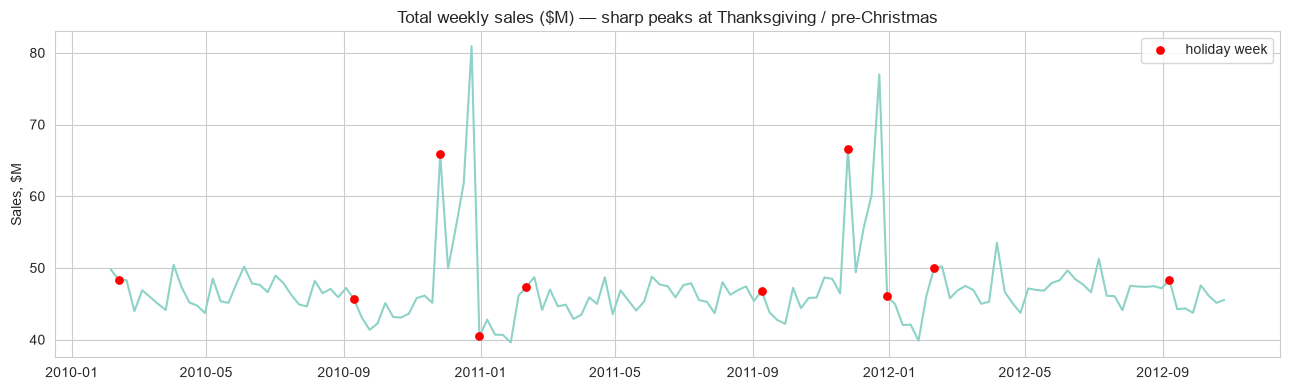

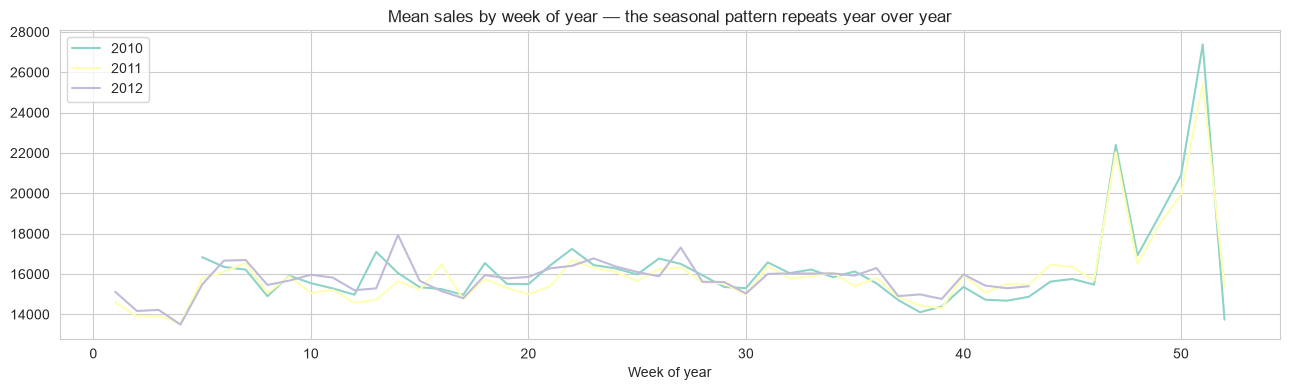

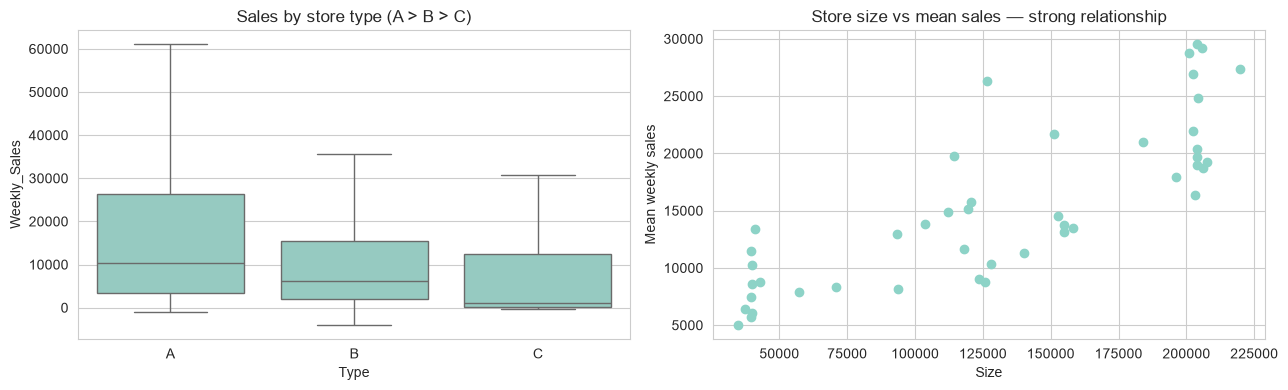

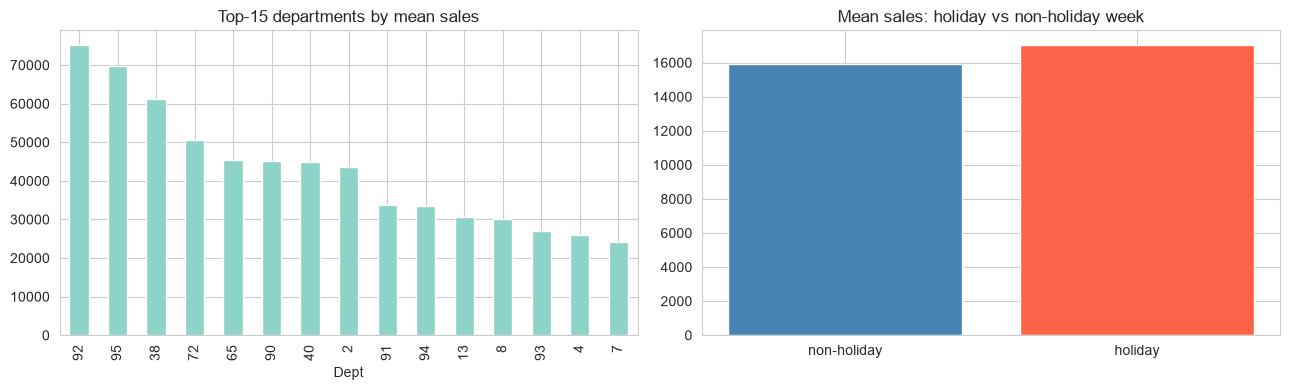

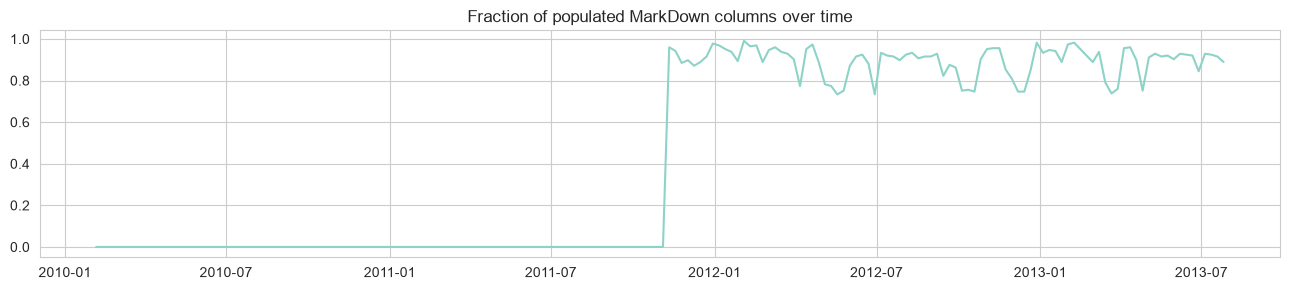

🏃 View run LightGBM_EDA at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/0/runs/6078fe4c70be4aeab0ac61e79f6852f8
🧪 View experiment at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/0


7278

In [7]:
train_m = prep.merge_side(train_raw, features_clean, stores_raw)

fig, ax = plt.subplots(figsize=(13, 4))
tot = train_raw.groupby("Date").Weekly_Sales.sum() / 1e6
ax.plot(tot.index, tot.values, lw=1.5)
hol = train_raw.groupby("Date").IsHoliday.first()
ax.scatter(tot.index[hol], tot[hol], color="red", zorder=5, s=28, label="holiday week")
ax.set_title("Total weekly sales ($M) — sharp peaks at Thanksgiving / pre-Christmas")
ax.set_ylabel("Sales, $M"); ax.legend()
plt.tight_layout(); plt.savefig("pictures/eda_total_sales.png", dpi=120); plt.show()

# seasonality by week-of-year, overlaid across years
fig, ax = plt.subplots(figsize=(13, 4))
t = train_raw.copy(); t["WOY"] = t.Date.dt.isocalendar().week.astype(int); t["Y"] = t.Date.dt.year
for y, g in t.groupby("Y"):
    s = g.groupby("WOY").Weekly_Sales.mean()
    ax.plot(s.index, s.values, label=str(y))
ax.set_title("Mean sales by week of year — the seasonal pattern repeats year over year")
ax.set_xlabel("Week of year"); ax.legend()
plt.tight_layout(); plt.savefig("pictures/eda_seasonality.png", dpi=120); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.boxplot(data=train_m.sample(min(80000, len(train_m)), random_state=SEED),
            x="Type", y="Weekly_Sales",
            order=list("ABC"), showfliers=False, ax=axes[0])
axes[0].set_title("Sales by store type (A > B > C)")
ssize = train_m.groupby("Store").agg(Size=("Size", "first"), Sales=("Weekly_Sales", "mean"))
axes[1].scatter(ssize.Size, ssize.Sales)
axes[1].set_title("Store size vs mean sales — strong relationship")
axes[1].set_xlabel("Size"); axes[1].set_ylabel("Mean weekly sales")
plt.tight_layout(); plt.savefig("pictures/eda_store_type.png", dpi=120); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
dep = train_raw.groupby("Dept").Weekly_Sales.mean().sort_values(ascending=False).head(15)
dep.plot(kind="bar", ax=axes[0]); axes[0].set_title("Top-15 departments by mean sales")
hh = train_raw.groupby("IsHoliday").Weekly_Sales.mean()
axes[1].bar(["non-holiday", "holiday"], hh.values, color=["steelblue", "tomato"])
axes[1].set_title("Mean sales: holiday vs non-holiday week")
plt.tight_layout(); plt.savefig("pictures/eda_depts_holiday.png", dpi=120); plt.show()

# MarkDown availability over time (does not exist before Nov 2011)
fig, ax = plt.subplots(figsize=(13, 3))
mdav = features_raw.set_index("Date")[MD_COLS].notna().mean(axis=1).groupby(level=0).mean()
ax.plot(mdav.index, mdav.values)
ax.set_title("Fraction of populated MarkDown columns over time")
plt.tight_layout(); plt.savefig("pictures/eda_markdown.png", dpi=120); plt.show()

with mlflow.start_run(run_name=f"{ARCH}_EDA"):
    for p in ["eda_total_sales", "eda_seasonality", "eda_store_type",
              "eda_depts_holiday", "eda_markdown"]:
        mlflow.log_artifact(f"pictures/{p}.png")
    mlflow.log_metrics({
        "corr_size_sales": float(ssize.Size.corr(ssize.Sales)),
        "holiday_uplift": float(hh[True] / hh[False] - 1),
    })
del train_m; gc.collect()


## Feature Engineering

A tree model cannot see "time" by itself, so we turn the time series into a
tabular problem. The key constraint: **the test set extends 39 weeks into the
future**, so short lags (lag-1, lag-4) are unusable without recursive
forecasting. Instead, lag-52 / lag-104 (same week of previous years) are
available in train for **every** test date — this is a **direct multi-horizon
strategy** with no error accumulation.

Feature groups (46 features, built by `preprocessing.WalmartFeatureBuilder`):
1. **Calendar** — Year, Month, WeekOfYear, WeekIndex, four holiday flags,
   days-to-holiday distances, `Pre_Christmas_Days` (how many pre-Christmas
   shopping days fall into the week — the winning solution's key insight).
2. **Store** — Size, Type (one-hot), Store/Dept IDs (legitimate split features
   for trees; one-hot for 81 departments would only fragment splits).
3. **Economy** — Temperature, Fuel_Price, CPI, Unemployment, MarkDown1-5
   (+ sum, + missing flag).
4. **History (lags/aggregates)** — Lag_52 (±1 week and their mean), Lag_104,
   (Store, Dept, WeekOfYear) mean, (Store, Dept) mean/median/std, last-13-week
   level, (Dept, WeekOfYear) median, and a fallback chain for the 11 (Store,
   Dept) pairs that appear only in test.

The builder is an sklearn transformer: `fit(X, y)` memorises history and side
tables, `transform(X)` runs on **raw, unprocessed** `test.csv` rows — giving us
the end-to-end Pipeline required by the assignment. During validation/CV it is
re-fitted on each fold's past only, so there is no leakage.


In [8]:
# Build feature matrices: the builder is fitted on train_part only (no leakage)
t0 = time.time()
FB = WalmartFeatureBuilder(features_clean, stores_raw, anchor=TRAIN_START).fit(
    train_part[BASE_COLS], train_part.Weekly_Sales)
X_tr,  y_tr  = FB.transform(train_part[BASE_COLS]), train_part.Weekly_Sales.values
X_val, y_val = FB.transform(val_part[BASE_COLS]),   val_part.Weekly_Sales.values
val_is_holiday = val_part.IsHoliday.values
w_tr  = np.where(train_part.IsHoliday, 5.0, 1.0)   # WMAE weights used in training
w_val = np.where(val_part.IsHoliday,   5.0, 1.0)
print(f"features built in {time.time()-t0:.1f}s | X_tr {X_tr.shape} | X_val {X_val.shape}")

with mlflow.start_run(run_name=f"{ARCH}_Feature_Engineering"):
    mlflow.log_params({
        "n_features": X_tr.shape[1],
        "lag_strategy": "direct multi-horizon: lag52(+/-1), lag104, no recursive lags",
        "history_aggregates": "SD_WOY_Mean, SD stats, SD_Recent13, Dept_WOY_Med, fallbacks",
        "anchor": str(TRAIN_START.date()),
    })
    mlflow.log_dict({"features": list(X_tr.columns)}, "feature_list.json")


features built in 15.2s | X_tr (383040, 46) | X_val (38530, 46)
🏃 View run LightGBM_Feature_Engineering at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/0/runs/b1dc19bcd3e543fb9cdeae87c158f8bc
🧪 View experiment at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/0


## Baseline — seasonal naive

Before any model we need the bar: "same week last year" is a famously strong baseline in this competition.

In [9]:
# Seasonal-naive baseline: prediction = same week last year (with fallback).
# This is the bar that any "clever" model must clear.
naive_wmae = wmae(y_val, X_val["Lag_52"].values, val_is_holiday)
expected_wmae = wmae(y_val, X_val["Expected"].values, val_is_holiday)
with mlflow.start_run(run_name=f"{ARCH}_Baseline_SeasonalNaive"):
    mlflow.log_metric("val_wmae_lag52_naive", naive_wmae)
    mlflow.log_metric("val_wmae_expected_woy_mean", expected_wmae)
print(f"seasonal naive (lag52) val WMAE = {naive_wmae:,.1f}")
print(f"(Store,Dept,WOY)-mean  val WMAE = {expected_wmae:,.1f}")


🏃 View run LightGBM_Baseline_SeasonalNaive at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/0/runs/2b6e6814a6ab48aaaf6af373cb915da5
🧪 View experiment at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/0
seasonal naive (lag52) val WMAE = 1,704.0
(Store,Dept,WOY)-mean  val WMAE = 1,796.9


## Model training helper

Early stopping on the validation set + WMAE scoring.

In [10]:
import lightgbm as lgb
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor

DEFAULT_PARAMS = dict(objective="l1", learning_rate=0.05, num_leaves=127,
                      feature_fraction=0.9, bagging_fraction=0.9, bagging_freq=1,
                      min_child_samples=20, n_estimators=3000,
                      random_state=SEED, n_jobs=-1, verbosity=-1)

def fit_eval(params, X_tr, y_tr, w_tr, X_val, y_val, w_val,
             use_weights=True, log_target=False):
    """Train LightGBM with early stopping; return (model, val_WMAE, pred).
    objective='l1' minimises MAE directly, and sample_weight=5 on holiday weeks
    makes the training loss exactly the competition WMAE."""
    p = dict(DEFAULT_PARAMS); p.update(params)
    yt = log1p_clip(y_tr) if log_target else y_tr
    yv = log1p_clip(y_val) if log_target else y_val
    model = lgb.LGBMRegressor(**p)
    kw = dict(eval_set=[(X_val, yv)],
              callbacks=[lgb.early_stopping(150, verbose=False), lgb.log_evaluation(0)])
    if use_weights:
        kw["sample_weight"] = w_tr
        kw["eval_sample_weight"] = [w_val]
    model.fit(X_tr, yt, **kw)
    pred = model.predict(X_val)
    if log_target:
        pred = expm1_inv(pred)
    return model, wmae(y_val, pred, w_val == 5.0), pred

def best_iter(model):
    return int(model.best_iteration_ or model.n_estimators)

def make_regressor(params, n_estimators, log_target):
    p = dict(DEFAULT_PARAMS); p.update(params); p["n_estimators"] = n_estimators
    reg = lgb.LGBMRegressor(**p)
    if log_target:
        reg = TransformedTargetRegressor(regressor=reg, func=log1p_clip,
                                         inverse_func=expm1_inv, check_inverse=False)
    return reg


## Feature Selection

Trees tolerate correlated features (the tree just picks one of them), but noisy
columns slow training and raise overfitting risk. We compare 4 logical subsets
plus an importance-based top-25, each with the same default model on the same
time-based holdout (results logged in the `LightGBM_Feature_Selection` run):

* `all` — every feature;
* `no_markdown` — MarkDowns exist only in the last train year (are they noise?);
* `no_econ` — drop macro features (CPI, Fuel, Temp, Unemployment) — weekly
  macro signal is known to be weak in this competition;
* `ts_only` — calendar + history only;
* `top25` — best 25 features by gain importance of the `all` model.


all          (46 features): val WMAE = 1,633.6
no_markdown  (39 features): val WMAE = 1,635.8
no_econ      (42 features): val WMAE = 1,657.1
ts_only      (35 features): val WMAE = 1,667.4
top25        (25 features): val WMAE = 1,615.0
🏃 View run LightGBM_Feature_Selection at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/0/runs/07762e8274f944f5bbf862ce7a068bde
🧪 View experiment at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/0
selected feature set: top25


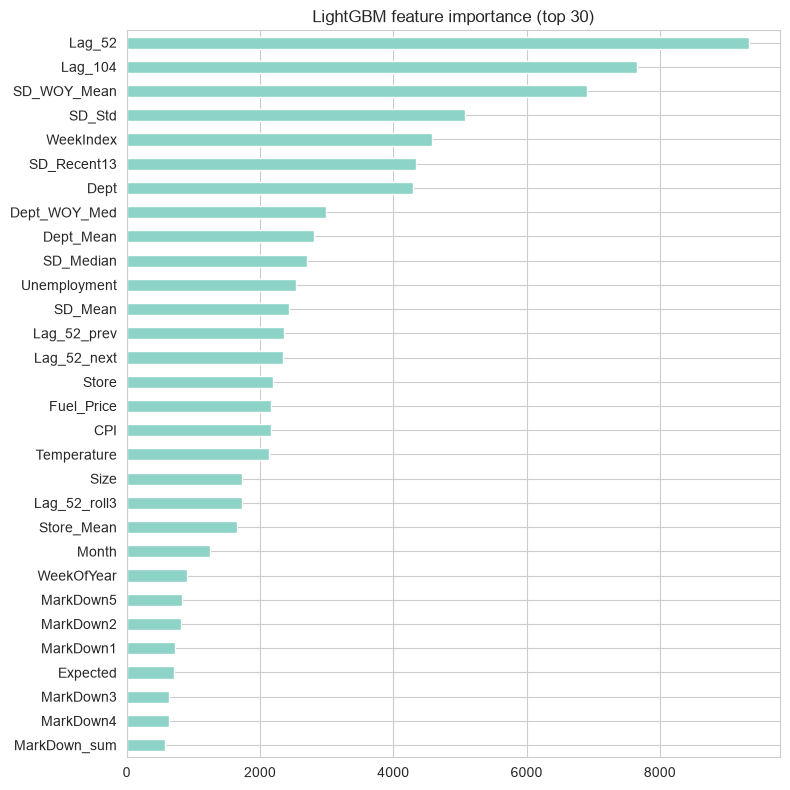

In [11]:
results_fs, models_fs = {}, {}
with mlflow.start_run(run_name=f"{ARCH}_Feature_Selection"):
    for fs in ["all", "no_markdown", "no_econ", "ts_only"]:
        cols = feature_columns(fs)
        m, s, _ = fit_eval({}, X_tr[cols], y_tr, w_tr, X_val[cols], y_val, w_val)
        results_fs[fs], models_fs[fs] = s, m
        mlflow.log_metric(f"wmae_{fs}", s)
        print(f"{fs:12s} ({len(cols):2d} features): val WMAE = {s:,.1f}")
    imp = pd.Series(models_fs["all"].feature_importances_,
                    index=feature_columns("all")).sort_values(ascending=False)
    TOPK_COLS = imp.head(25).index.tolist()
    m, s, _ = fit_eval({}, X_tr[TOPK_COLS], y_tr, w_tr, X_val[TOPK_COLS], y_val, w_val)
    results_fs["top25"] = s
    mlflow.log_metric("wmae_top25", s)
    print(f"{'top25':12s} (25 features): val WMAE = {s:,.1f}")

    SELECTED_SET = min(results_fs, key=results_fs.get)
    SELECTED_FS = TOPK_COLS if SELECTED_SET == "top25" else SELECTED_SET
    SEL_COLS = feature_columns(SELECTED_FS)
    mlflow.log_param("selected_set", SELECTED_SET)
    mlflow.log_dict({"selected_columns": SEL_COLS}, "selected_columns.json")
print("selected feature set:", SELECTED_SET)

fig, ax = plt.subplots(figsize=(8, 8))
imp.head(30)[::-1].plot(kind="barh", ax=ax)
ax.set_title(f"{ARCH} feature importance (top 30)")
plt.tight_layout(); plt.savefig(f"pictures/{ARCH.lower()}_feature_importance.png", dpi=120)
plt.show()


## Hyperparameter tuning — Optuna (TPE)

Instead of grid search we use Optuna's TPE sampler: each new trial is drawn
based on previous results, finding much better configurations within the same
budget. Every trial is logged as a nested MLflow run inside
`LightGBM_HPO_Optuna`. We do not search `n_estimators` — early stopping finds
the optimal iteration count for every configuration for free.

`N_TRIALS` / `TIMEOUT` control the time budget (30 trials take roughly
20-40 minutes even on CPU).


  0%|          | 0/30 [00:00<?, ?it/s]

🏃 View run LightGBM_HPO_trial_00 at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/0/runs/31e52f4e9c8b4624ad464970e1034be9
🧪 View experiment at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/0


Best trial: 0. Best value: 1577.95:   3%|▎         | 1/30 [03:31<1:42:01, 211.09s/it, 211.09/2700 seconds]

🏃 View run LightGBM_HPO_trial_01 at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/0/runs/d0068b6869294561a994f2786af71a18
🧪 View experiment at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/0


Best trial: 0. Best value: 1577.95:   7%|▋         | 2/30 [04:44<1:00:39, 129.99s/it, 284.31/2700 seconds]

...

🏃 View run LightGBM_HPO_trial_14 at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/0/runs/3d1474883c6c49558eadf3ae9b5f8f46
🧪 View experiment at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/0


Best trial: 12. Best value: 1542.22:  50%|█████     | 15/30 [44:47<33:43, 134.88s/it, 2687.86/2700 seconds]

🏃 View run LightGBM_HPO_trial_15 at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/0/runs/e71107f6115b43d7bb8e18ba82cc766c
🧪 View experiment at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/0


Best trial: 12. Best value: 1542.22:  53%|█████▎    | 16/30 [46:17<40:29, 173.57s/it, 2777.13/2700 seconds]


🏃 View run LightGBM_HPO_Optuna at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/0/runs/debdcdd81ba142ce9cd65338b512244d
🧪 View experiment at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/0
best val WMAE: 1542.2
best params: {'learning_rate': 0.07233071216253134, 'num_leaves': 32, 'min_child_samples': 22, 'feature_fraction': 0.6021034892036463, 'bagging_fraction': 0.8520091155081155, 'lambda_l1': 1.415355413157164e-08, 'lambda_l2': 0.08422639223151968}


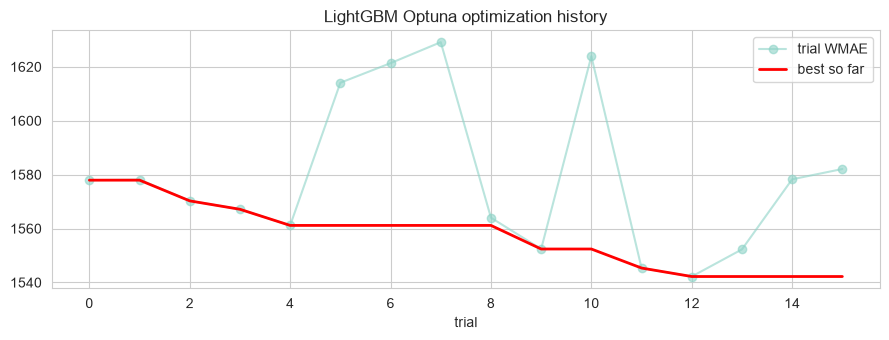

In [12]:
+import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

N_TRIALS = 30          # <-- adjust to your time budget
TIMEOUT  = 60 * 45     # max 45 minutes

def suggest_params(trial):
    return {
        "learning_rate":     trial.suggest_float("learning_rate", 0.02, 0.15, log=True),
        "num_leaves":        trial.suggest_int("num_leaves", 31, 511, log=True),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100, log=True),
        "feature_fraction":  trial.suggest_float("feature_fraction", 0.6, 1.0),
        "bagging_fraction":  trial.suggest_float("bagging_fraction", 0.6, 1.0),
        "lambda_l1":         trial.suggest_float("lambda_l1", 1e-8, 10.0, log=True),
        "lambda_l2":         trial.suggest_float("lambda_l2", 1e-8, 10.0, log=True),
    }

def objective(trial):
    params = suggest_params(trial)
    with mlflow.start_run(run_name=f"{ARCH}_HPO_trial_{trial.number:02d}", nested=True):
        _, score, _ = fit_eval(params, X_tr[SEL_COLS], y_tr, w_tr,
                               X_val[SEL_COLS], y_val, w_val)
        mlflow.log_params(params)
        mlflow.log_metric("val_wmae", score)
    return score

with mlflow.start_run(run_name=f"{ARCH}_HPO_Optuna"):
    study = optuna.create_study(direction="minimize",
                                sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(objective, n_trials=N_TRIALS, timeout=TIMEOUT, show_progress_bar=True)
    BEST_PARAMS = study.best_params
    mlflow.log_params({f"best_{k}": v for k, v in BEST_PARAMS.items()})
    mlflow.log_metric("best_val_wmae", study.best_value)
    mlflow.log_metric("n_trials", len(study.trials))
print("best val WMAE:", round(study.best_value, 1))
print("best params:", BEST_PARAMS)

hist = pd.Series([t.value for t in study.trials if t.value is not None])
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(hist.values, "o-", alpha=0.6, label="trial WMAE")
ax.plot(hist.cummin().values, "r-", lw=2, label="best so far")
ax.set_title(f"{ARCH} Optuna optimization history"); ax.set_xlabel("trial"); ax.legend()
plt.tight_layout(); plt.savefig(f"pictures/{ARCH.lower()}_optuna.png", dpi=120); plt.show()


## Loss / target experiments

Two questions checked with the best hyperparameters (a separate MLflow run):
1. **sample_weight (w=5 holiday) during training** — WMAE penalises holiday
   weeks 5x, so the model should arguably see them as 5x more important during
   training too. But the validation window contains only one holiday week, so
   the effect must be verified empirically, not assumed;
2. **log1p(target)** — sales are right-skewed; the log reduces the dominance of
   large stores, but an MAE objective in log space is no longer WMAE in dollars,
   so it may just as well hurt.


In [13]:
combo_results = {}
with mlflow.start_run(run_name=f"{ARCH}_Loss_Target_Experiments"):
    for use_w in [True, False]:
        for log_t in [False, True]:
            name = f"weights={use_w}, log_target={log_t}"
            _, s, _ = fit_eval(BEST_PARAMS, X_tr[SEL_COLS], y_tr, w_tr,
                               X_val[SEL_COLS], y_val, w_val,
                               use_weights=use_w, log_target=log_t)
            combo_results[(use_w, log_t)] = s
            mlflow.log_metric(f"wmae_w{int(use_w)}_log{int(log_t)}", s)
            print(f"{name:35s} -> val WMAE = {s:,.1f}")
    USE_WEIGHTS, LOG_TARGET = min(combo_results, key=combo_results.get)
    mlflow.log_param("chosen_use_weights", USE_WEIGHTS)
    mlflow.log_param("chosen_log_target", LOG_TARGET)
print(f"\nchosen config: use_weights={USE_WEIGHTS}, log_target={LOG_TARGET}")


weights=True, log_target=False      -> val WMAE = 1,542.2
weights=True, log_target=True       -> val WMAE = 1,563.7
weights=False, log_target=False     -> val WMAE = 1,532.2
weights=False, log_target=True      -> val WMAE = 1,536.1
🏃 View run LightGBM_Loss_Target_Experiments at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/0/runs/7ad05ff81edf41e1adbdfd4250ad5e48
🧪 View experiment at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/0

chosen config: use_weights=False, log_target=False


## Cross-validation — expanding window

Plain K-Fold is forbidden for time series. We use **expanding-window CV**
(`evaluation.expanding_folds`): every fold trains on the past and validates on
the following 13 weeks. Together the folds cover Feb-Oct 2012, so both Super
Bowl and Labor Day appear in validation. The FeatureBuilder is **re-fitted from
scratch** on each fold's past — no leakage.


In [14]:
N_FOLDS = 3
cv_scores = []
with mlflow.start_run(run_name=f"{ARCH}_CrossValidation"):
    for k, tr_k, vl_k, lo, hi in ev.expanding_folds(train_raw, n_folds=N_FOLDS):
        fb_k = WalmartFeatureBuilder(features_clean, stores_raw, anchor=TRAIN_START,
                                     feature_set=SELECTED_FS).fit(
            tr_k[BASE_COLS], tr_k.Weekly_Sales)
        Xk, Xv = fb_k.transform(tr_k[BASE_COLS]), fb_k.transform(vl_k[BASE_COLS])
        wk = np.where(tr_k.IsHoliday, 5.0, 1.0)
        wv = np.where(vl_k.IsHoliday, 5.0, 1.0)
        _, s, _ = fit_eval(BEST_PARAMS, Xk, tr_k.Weekly_Sales.values, wk,
                           Xv, vl_k.Weekly_Sales.values, wv,
                           use_weights=USE_WEIGHTS, log_target=LOG_TARGET)
        cv_scores.append(s)
        mlflow.log_metric(f"cv_wmae_fold{k+1}", s)
        print(f"fold {k+1}: val {lo.date()} -> {hi.date()}  WMAE = {s:,.1f}")
    mlflow.log_metric("cv_wmae_mean", float(np.mean(cv_scores)))
    mlflow.log_metric("cv_wmae_std", float(np.std(cv_scores)))
print(f"\nCV WMAE = {np.mean(cv_scores):,.1f} +/- {np.std(cv_scores):,.1f}")


fold 1: val 2012-07-27 -> 2012-10-26  WMAE = 1,532.2
fold 2: val 2012-04-27 -> 2012-07-27  WMAE = 1,655.6
fold 3: val 2012-01-27 -> 2012-04-27  WMAE = 2,556.3
🏃 View run LightGBM_CrossValidation at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/0/runs/8663eaad02c5467ab2707e0b3c71fe48
🧪 View experiment at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/0

CV WMAE = 1,914.7 +/- 456.5


## Final pipeline + submission

1. Determine the final iteration count with the chosen config (early stopping's
   `best_iter` × 1.1 — a bit more is allowed on full data since there is more
   of it);
2. Fit `Pipeline(WalmartFeatureBuilder -> model)` on the **entire** train set;
3. Log the pipeline to MLflow (sklearn flavor) with
   `code_paths=["preprocessing.py", "evaluation.py"]` — the builder class lives
   in preprocessing.py, so the module is bundled into the model artifact and
   `model_inference.ipynb` can load it from the Registry anywhere;
4. Generate the Kaggle submission.

> **REGISTER_AS_BEST**: after running every architecture, compare val WMAE
> scores and set True only in the winning notebook — the model is then
> registered in the Model Registry as `WalmartBestModel`.


In [16]:
REGISTER_AS_BEST = False   # <-- True only in the winning architecture's notebook!

# best_iter from a validation refit with the final config
model_v, final_val_wmae, val_pred = fit_eval(
    BEST_PARAMS, X_tr[SEL_COLS], y_tr, w_tr, X_val[SEL_COLS], y_val, w_val,
    use_weights=USE_WEIGHTS, log_target=LOG_TARGET)
N_FINAL = int(best_iter(model_v) * 1.1) + 50
print(f"final val WMAE = {final_val_wmae:,.1f} | n_estimators(final) = {N_FINAL}")

pipeline = Pipeline([
    ("features", WalmartFeatureBuilder(features_clean, stores_raw,
                                       anchor=TRAIN_START, feature_set=SELECTED_FS)),
    ("model", make_regressor(BEST_PARAMS, N_FINAL, LOG_TARGET)),
])
w_full = np.where(train_raw.IsHoliday, 5.0, 1.0)
fit_kw = {"model__sample_weight": w_full} if USE_WEIGHTS else {}
t0 = time.time()
pipeline.fit(train_raw[BASE_COLS], train_raw.Weekly_Sales.values, **fit_kw)
print(f"full-data fit: {time.time()-t0:.0f}s")

# sanity: the pipeline runs directly on raw test rows
test_pred = pipeline.predict(test_raw[BASE_COLS])
assert len(test_pred) == len(test_raw) and np.isfinite(test_pred).all()

with mlflow.start_run(run_name=f"{ARCH}_Final_Pipeline"):
    mlflow.log_params({**{f"hp_{k}": v for k, v in BEST_PARAMS.items()},
                       "n_estimators": N_FINAL, "use_weights": USE_WEIGHTS,
                       "log_target": LOG_TARGET, "feature_set": str(SELECTED_SET),
                       "cv_folds": N_FOLDS})
    mlflow.log_metric("val_wmae", final_val_wmae)
    mlflow.log_metric("cv_wmae_mean", float(np.mean(cv_scores)))
    # attach the figures produced by this notebook to the final run
    for _p in [f"pictures/{ARCH.lower()}_feature_importance.png",
               f"pictures/{ARCH.lower()}_optuna.png"]:
        if os.path.exists(_p):
            mlflow.log_artifact(_p)
    mlflow.sklearn.log_model(
        pipeline, "model", code_paths=CODE_PATHS,
        serialization_format="cloudpickle",   # skops (new default) rejects custom classes
        registered_model_name="WalmartBestModel" if REGISTER_AS_BEST else None)
    run_id = mlflow.active_run().info.run_id
print("pipeline logged, run_id =", run_id)


final val WMAE = 1,532.2 | n_estimators(final) = 1051
full-data fit: 19s


2026/07/09 15:23:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run LightGBM_Final_Pipeline at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/0/runs/94e81223d4d84ff780d7a47e800bc4a9
🧪 View experiment at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/0


MlflowException: The sklearn model could not be serialized in the skops serialization format. skops does not support custom functions or classes that are not defined at the top level. To work around this limitation, you can set the serialization_format 'cloudpickle', while exercising caution due to the possible arbitrary code during model deserialization using CloudPickle.

In [17]:
with mlflow.start_run(run_name=f"{ARCH}_Final_Pipeline"):
    mlflow.log_params({**{f"hp_{k}": v for k, v in BEST_PARAMS.items()},
                       "n_estimators": N_FINAL, "use_weights": USE_WEIGHTS,
                       "log_target": LOG_TARGET, "feature_set": str(SELECTED_SET),
                       "cv_folds": N_FOLDS})
    mlflow.log_metric("val_wmae", final_val_wmae)
    mlflow.log_metric("cv_wmae_mean", float(np.mean(cv_scores)))
    for _p in [f"pictures/{ARCH.lower()}_feature_importance.png",
               f"pictures/{ARCH.lower()}_optuna.png"]:
        if os.path.exists(_p):
            mlflow.log_artifact(_p)
    mlflow.sklearn.log_model(
        pipeline, "model", code_paths=CODE_PATHS,
        serialization_format="cloudpickle",
        registered_model_name="WalmartBestModel" if REGISTER_AS_BEST else None)
    run_id = mlflow.active_run().info.run_id
print("pipeline logged, run_id =", run_id)

2026/07/09 15:27:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/09 15:27:52 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run LightGBM_Final_Pipeline at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/0/runs/319b583be73b45a090af73c2b6bc44d4
🧪 View experiment at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/0
pipeline logged, run_id = 319b583be73b45a090af73c2b6bc44d4


In [18]:
sub = ev.make_submission(test_raw, test_pred, f"submission_{ARCH}.csv")
print(sub.head())
print("saved:", f"submission_{ARCH}.csv")


               Id  Weekly_Sales
0  1_1_2012-11-02  36496.535346
1  1_1_2012-11-09  19954.147598
2  1_1_2012-11-16  19431.564917
3  1_1_2012-11-23  19687.545260
4  1_1_2012-11-30  23877.382853
saved: submission_LightGBM.csv


### Post-processing: Christmas week shift

A known trick from the winning solution (David Thaler): Christmas week
(w/e 2012-12-28) of the test year contains **2.5 more** pre-Christmas shopping
days than the 2010/2011 weeks the lag features learned from. So for weeks 49-52
we move a `2.5/7` fraction of the previous week's prediction forward
(implemented in `evaluation.apply_christmas_shift`). This cannot be validated
locally (no Christmas in the validation window) — upload both files to Kaggle
and compare (historically the shift improved WMAE by ~20-40 points).


In [19]:
sub_shift = ev.apply_christmas_shift(sub, test_raw)
sub_shift.to_csv(f"submission_{ARCH}_xmas_shift.csv", index=False)
chg = (sub_shift.Weekly_Sales - sub.Weekly_Sales).abs().sum()
print(f"saved submission_{ARCH}_xmas_shift.csv | total abs change = {chg:,.0f}$")


saved submission_LightGBM_xmas_shift.csv | total abs change = 22,396,730$


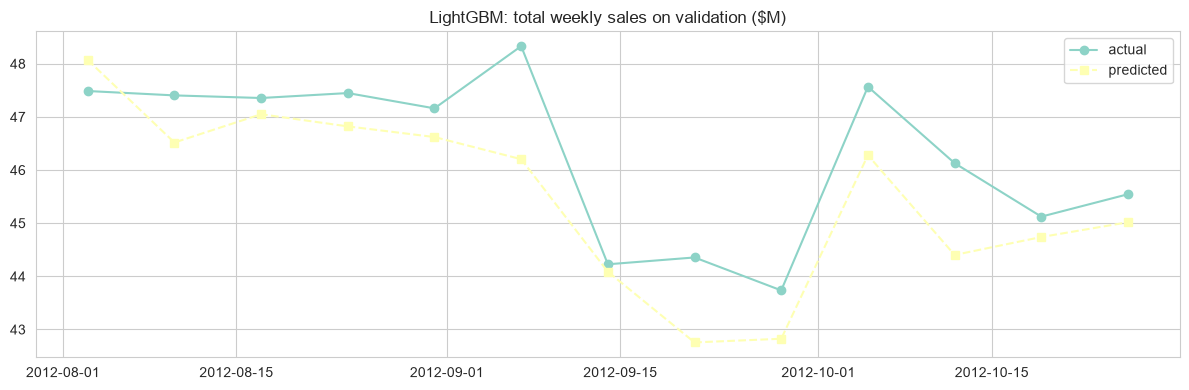

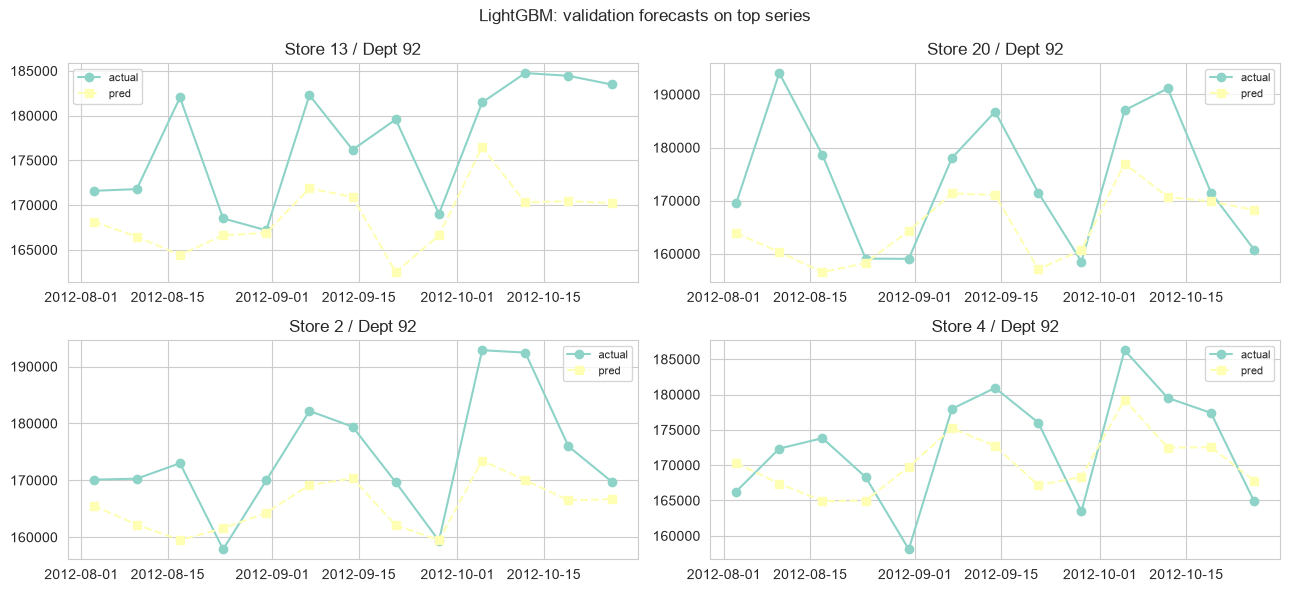

In [20]:
# Validation visualisations for the README
vp = val_part[["Store", "Dept", "Date", "Weekly_Sales"]].copy()
vp["pred"] = val_pred

fig, ax = plt.subplots(figsize=(12, 4))
a = vp.groupby("Date").Weekly_Sales.sum() / 1e6
p = vp.groupby("Date").pred.sum() / 1e6
ax.plot(a.index, a.values, "o-", label="actual")
ax.plot(p.index, p.values, "s--", label="predicted")
ax.set_title(f"{ARCH}: total weekly sales on validation ($M)")
ax.legend()
plt.tight_layout(); plt.savefig(f"pictures/{ARCH.lower()}_val_total.png", dpi=120); plt.show()

top4 = (vp.groupby(["Store", "Dept"]).Weekly_Sales.mean()
          .sort_values(ascending=False).head(4).index)
fig, axes = plt.subplots(2, 2, figsize=(13, 6))
for ax, (s_, d_) in zip(axes.ravel(), top4):
    g = vp[(vp.Store == s_) & (vp.Dept == d_)].sort_values("Date")
    ax.plot(g.Date, g.Weekly_Sales, "o-", label="actual")
    ax.plot(g.Date, g.pred, "s--", label="pred")
    ax.set_title(f"Store {s_} / Dept {d_}"); ax.legend(fontsize=8)
plt.suptitle(f"{ARCH}: validation forecasts on top series")
plt.tight_layout(); plt.savefig(f"pictures/{ARCH.lower()}_val_series.png", dpi=120); plt.show()


## Summary

Final numbers to copy into the README comparison:
* seasonal-naive baseline WMAE (the bar);
* best feature set from feature selection;
* Optuna's best config and val/CV WMAE;
* Kaggle scores (both submissions — with and without the Christmas shift).